# Importancia de la estadística para tomar decisiones

La estadística no sirve solo para "sacar números". Sirve para resumir información, detectar patrones, comparar grupos y tomar decisiones con más criterio. En este tutorial veremos por qué medidas como la media, la moda, la desviación estándar, la varianza, los cuartiles y los percentiles ayudan a responder preguntas reales.

## Requisitos

Para desarrollar este tutorial necesitarás:

* Importar archivos con `pandas`.
* Consultar columnas y filas de un `DataFrame`.
* Interpretar tablas y gráficos sencillos.

## Objetivos

Al final de este tutorial podrás:

**1.** Explicar por qué la estadística es importante en un análisis de datos. <br>
**2.** Interpretar media, mediana, moda, varianza y desviación estándar. <br>
**3.** Utilizar cuartiles y percentiles para priorizar decisiones. <br>
**4.** Entender qué significa una distribución normal. <br>
**5.** Reconocer qué cambia cuando los datos no siguen una distribución normal.

## 1. Un problema real

Imagina que eres parte del equipo académico de un curso. Tienes datos de estudiantes y quieres responder preguntas como:

* ¿Cuál es el rendimiento típico del grupo?
* ¿Los estudiantes son consistentes o hay mucha variación?
* ¿Quiénes necesitan apoyo prioritario?
* ¿Qué recurso de estudio es más usado?
* ¿Hay comportamientos atípicos?

La estadística permite pasar de una tabla larga de datos a decisiones concretas.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ruta = Path("Archivos") / "rendimiento_estudiantes.csv"
datos = pd.read_csv(ruta)
datos.head()

,estudiante_id,grupo,horas_estudio_semana,nota_final,tiempo_plataforma_min,asistencia_pct,entregas_tarde,recurso_favorito
0,1,A,4,3.2,85,78,3,Videos
1,2,A,6,3.8,120,88,1,Guias
2,3,A,7,4.1,150,92,0,Videos
3,4,A,3,2.9,70,75,4,Clases en vivo
4,5,A,8,4.4,210,95,0,Videos


## 2. Conocer el dataset

Antes de calcular estadísticas, conviene revisar el tamaño de la base y entender qué representa cada columna.

In [2]:
print("Dimensiones:", datos.shape)
print("\nColumnas:")
print(list(datos.columns))

Dimensiones: (24, 8)

Columnas:
['estudiante_id', 'grupo', 'horas_estudio_semana', 'nota_final', 'tiempo_plataforma_min', 'asistencia_pct', 'entregas_tarde', 'recurso_favorito']


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   estudiante_id          24 non-null     int64  
 1   grupo                  24 non-null     object 
 2   horas_estudio_semana   24 non-null     int64  
 3   nota_final             24 non-null     float64
 4   tiempo_plataforma_min  24 non-null     int64  
 5   asistencia_pct         24 non-null     int64  
 6   entregas_tarde         24 non-null     int64  
 7   recurso_favorito       24 non-null     object 
dtypes: float64(1), int64(5), object(2)
memory usage: 1.6+ KB


En este archivo cada fila representa un estudiante. Tenemos variables de rendimiento (`nota_final`), esfuerzo (`horas_estudio_semana`), uso de plataforma (`tiempo_plataforma_min`), asistencia y un recurso favorito.

## 3. Media, mediana y moda

Estas medidas ayudan a responder una pregunta básica: **¿qué valor es representativo?**

In [4]:
media_nota = datos["nota_final"].mean()
mediana_nota = datos["nota_final"].median()
moda_recurso = datos["recurso_favorito"].mode()[0]

print("Media de la nota final:", round(media_nota, 2))
print("Mediana de la nota final:", round(mediana_nota, 2))
print("Moda del recurso favorito:", moda_recurso)

Media de la nota final: 3.65
Mediana de la nota final: 3.65
Moda del recurso favorito: Videos


### ¿Por qué es importante la media?

La **media** resume el nivel promedio del grupo. Si la nota promedio fuera muy baja, podríamos revisar si el curso está siendo demasiado exigente o si el grupo necesita refuerzo.

Pero la media tiene una debilidad: puede ser afectada por valores extremos.

### ¿Por qué también importa la mediana?

La **mediana** es el valor central. Si la media y la mediana son parecidas, la distribución suele estar más equilibrada. Si son muy distintas, podría haber asimetría o valores extremos.

En decisiones reales:

* Si la media de ingresos está muy por encima de la mediana, probablemente unos pocos valores altos están arrastrando el promedio.
* Si la media y la mediana de notas son similares, el promedio puede describir mejor al grupo.

### ¿Por qué importa la moda?

La **moda** es el valor o categoría más frecuente. Es especialmente útil en variables categóricas.

En este caso, la moda del `recurso_favorito` nos ayuda a decidir qué tipo de material prefieren los estudiantes. Si la mayoría usa videos, podría ser buena idea fortalecer ese formato.

In [5]:
datos["recurso_favorito"].value_counts()

recurso_favorito
Videos            11
Guias              6
Clases en vivo     4
Resumenes          3
Name: count, dtype: int64

## 4. Varianza y desviación estándar

Dos grupos pueden tener la misma media y aun así comportarse de manera muy distinta. Para eso sirven la **varianza** y la **desviación estándar**: miden qué tan dispersos están los datos.

In [6]:
varianza_nota = datos["nota_final"].var()
desviacion_nota = datos["nota_final"].std()

print("Varianza de la nota final:", round(varianza_nota, 3))
print("Desviación estándar de la nota final:", round(desviacion_nota, 3))

Varianza de la nota final: 0.53
Desviación estándar de la nota final: 0.728


La **varianza** mide la dispersión al cuadrado. La **desviación estándar** expresa esa dispersión en la misma unidad original de la variable, por eso suele ser más fácil de interpretar.

En decisiones reales:

* Una desviación estándar baja sugiere un grupo más homogéneo.
* Una desviación estándar alta sugiere brechas grandes entre estudiantes.
* Si la variación es alta, tal vez no basta una sola estrategia de enseñanza para todos.

In [7]:
grupo_estable = np.array([3.8, 3.9, 4.0, 4.1, 4.2])
grupo_variable = np.array([2.5, 3.0, 4.0, 4.8, 5.0])

print("Media grupo estable:", grupo_estable.mean())
print("Desviación grupo estable:", round(grupo_estable.std(ddof=1), 2))
print()
print("Media grupo variable:", grupo_variable.mean())
print("Desviación grupo variable:", round(grupo_variable.std(ddof=1), 2))

Media grupo estable: 4.0
Desviación grupo estable: 0.16

Media grupo variable: 3.8600000000000003
Desviación grupo variable: 1.09


Ambos grupos tienen medias parecidas, pero el segundo es mucho más disperso. La decisión cambia:

* En el grupo estable quizá basta mantener la estrategia.
* En el grupo variable puede ser necesario identificar subgrupos y ofrecer apoyos diferenciados.

## 5. Cuartiles y percentiles

A veces no basta con saber el promedio. Necesitamos ubicar a cada estudiante dentro del grupo. Para eso sirven los **cuartiles** y los **percentiles**.

In [8]:
cuartiles = datos["nota_final"].quantile([0.25, 0.50, 0.75])
percentil_90 = datos["nota_final"].quantile(0.90)
percentil_10 = datos["nota_final"].quantile(0.10)

print("Cuartiles de la nota final:")
print(cuartiles)
print()
print("Percentil 10:", round(percentil_10, 2))
print("Percentil 90:", round(percentil_90, 2))

Cuartiles de la nota final:
0.25    3.075
0.50    3.650
0.75    4.225
Name: nota_final, dtype: float64

Percentil 10: 2.73
Percentil 90: 4.57


### ¿Qué decisiones permiten?

* El **primer cuartil** indica el punto bajo el cual está el 25% inferior del grupo.
* El **tercer cuartil** marca el valor por debajo del cual está el 75% del grupo.
* El **percentil 90** ayuda a identificar estudiantes de desempeño sobresaliente.
* El **percentil 10** ayuda a priorizar intervención para quienes están en mayor riesgo.

In [9]:
estudiantes_apoyo = datos[datos["nota_final"] <= percentil_10][["estudiante_id", "nota_final", "horas_estudio_semana", "asistencia_pct"]]
estudiantes_destacados = datos[datos["nota_final"] >= percentil_90][["estudiante_id", "nota_final", "horas_estudio_semana", "asistencia_pct"]]

print("Estudiantes para apoyo prioritario:")
display(estudiantes_apoyo)
print("Estudiantes destacados:")
display(estudiantes_destacados)

Estudiantes para apoyo prioritario:


,estudiante_id,nota_final,horas_estudio_semana,asistencia_pct
6,7,2.7,2,68
11,12,2.4,1,60
22,23,2.6,2,66


Estudiantes destacados:


,estudiante_id,nota_final,horas_estudio_semana,asistencia_pct
7,8,4.6,9,97
10,11,4.8,10,98
18,19,4.9,12,99


Observa lo valioso de esta idea: la estadística no solo describe, también ayuda a **priorizar**.

## 6. La campana de Gauss y la normalidad

La **campana de Gauss** es la forma típica de una distribución normal: simétrica, con muchos valores cerca del centro y pocos valores en los extremos.

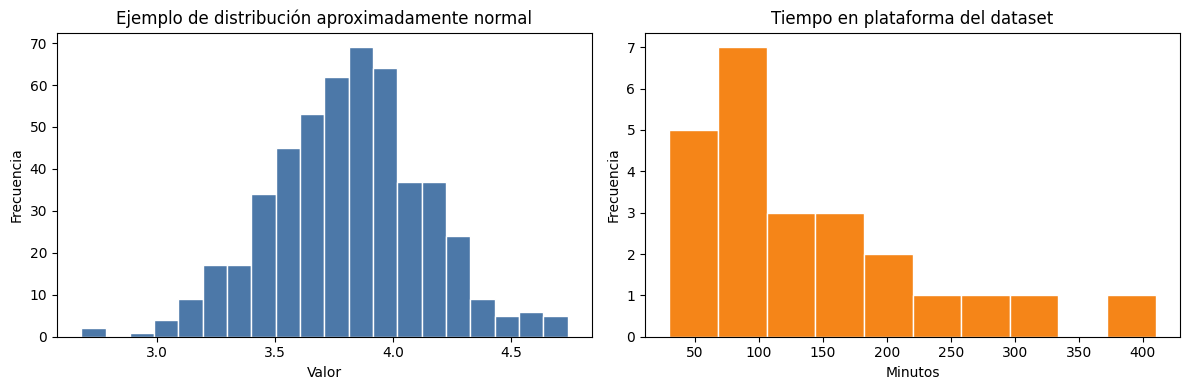

In [10]:
np.random.seed(10)
datos_normales = np.random.normal(loc=3.8, scale=0.35, size=500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(datos_normales, bins=20, color="#4C78A8", edgecolor="white")
axes[0].set_title("Ejemplo de distribución aproximadamente normal")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(datos["tiempo_plataforma_min"], bins=10, color="#F58518", edgecolor="white")
axes[1].set_title("Tiempo en plataforma del dataset")
axes[1].set_xlabel("Minutos")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

A la izquierda vemos una forma parecida a una campana. A la derecha puede aparecer una distribución más asimétrica. Esto pasa mucho en la vida real: no todas las variables siguen una distribución normal.

In [11]:
resumen_forma = pd.DataFrame({
    "variable": ["nota_final", "tiempo_plataforma_min"],
    "media": [datos["nota_final"].mean(), datos["tiempo_plataforma_min"].mean()],
    "mediana": [datos["nota_final"].median(), datos["tiempo_plataforma_min"].median()],
    "asimetria": [datos["nota_final"].skew(), datos["tiempo_plataforma_min"].skew()]
})

resumen_forma.round(3)

,variable,media,mediana,asimetria
0,nota_final,3.654,3.65,0.026
1,tiempo_plataforma_min,136.458,105.00,1.434


Si una variable tiene media y mediana parecidas, y además poca asimetría, puede comportarse de manera relativamente cercana a la normalidad. Si la asimetría es grande, conviene ser más cuidadosos.

## 7. ¿Qué pasa cuando los datos no están normales?

Esta es una de las preguntas más importantes en estadística aplicada.

Cuando los datos **no** son normales, pueden ocurrir varias cosas:

* La media deja de representar bien el "centro" del grupo.
* Los valores extremos pueden afectar mucho el promedio.
* La desviación estándar puede ser menos intuitiva si hay colas largas.
* Algunas pruebas estadísticas clásicas requieren más cuidado o métodos alternativos.

En esos casos, suele ser útil:

* Complementar con la **mediana**.
* Usar **cuartiles** y **percentiles**.
* Revisar gráficos como histogramas y diagramas de caja.
* Considerar transformaciones o métodos no paramétricos si el análisis lo requiere.

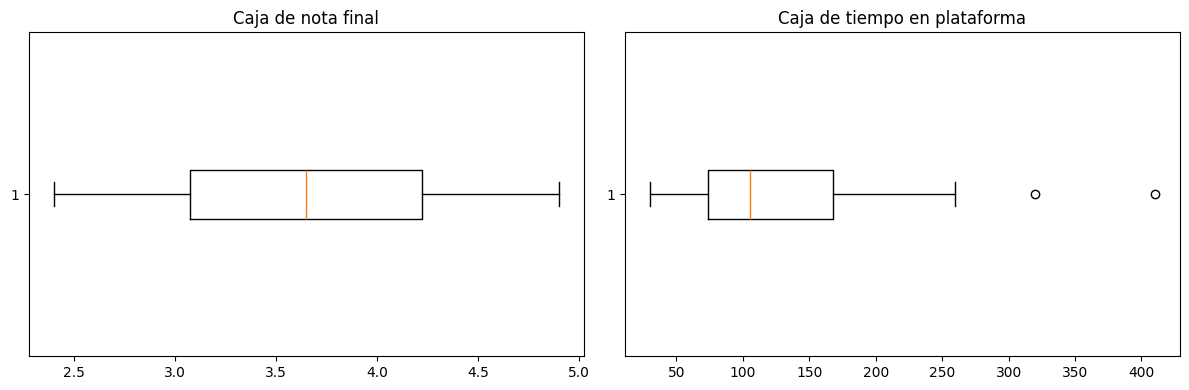

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(datos["nota_final"], vert=False)
axes[0].set_title("Caja de nota final")

axes[1].boxplot(datos["tiempo_plataforma_min"], vert=False)
axes[1].set_title("Caja de tiempo en plataforma")

plt.tight_layout()
plt.show()

## 8. Preguntas resueltas

A continuación, resolvemos preguntas frecuentes que suelen aparecer cuando se empieza a usar estadística.

**Pregunta 1. Si ya tengo la media, para qué necesito otras medidas?**  
**Respuesta.** Porque la media sola puede ocultar diferencias importantes. Dos grupos pueden tener el mismo promedio y comportarse de manera muy distinta en dispersión o asimetría.

**Pregunta 2. Cuándo es mejor usar la moda?**  
**Respuesta.** Cuando quieres saber qué categoría es la más común. Es muy útil en variables categóricas, como ciudad, canal, programa o recurso favorito.

**Pregunta 3. Qué decisión puedo tomar con la desviación estándar?**  
**Respuesta.** Puedes evaluar estabilidad o riesgo. Si la dispersión es alta, puede ser necesario segmentar a la población o diseñar estrategias diferentes para grupos distintos.

**Pregunta 4. Para qué sirven los cuartiles?**  
**Respuesta.** Sirven para dividir el grupo en zonas. Por ejemplo, puedes identificar el 25% con menor desempeño y diseñar apoyo focalizado.

**Pregunta 5. Para qué sirven los percentiles?**  
**Respuesta.** Sirven para ubicar observaciones en la distribución. Un estudiante en el percentil 90 está por encima de la mayoría del grupo. Un cliente en el percentil 95 de gasto puede merecer una estrategia especial.

**Pregunta 6. La campana de Gauss aparece siempre?**  
**Respuesta.** No. Muchas variables reales no son normales. Ingresos, tiempos de espera, número de compras o uso de plataformas suelen ser asimétricos.

**Pregunta 7. Si los datos no son normales, ya no sirven?**  
**Respuesta.** Sí sirven. Solo significa que debes interpretarlos con cuidado y quizá usar otras medidas o métodos más apropiados.

**Pregunta 8. Qué es más importante: calcular o interpretar?**  
**Respuesta.** Interpretar. En analítica, lo valioso no es solo obtener un número sino entender qué nos dice y qué decisión permite tomar.

## 9. Ejercicio de reflexión

Con base en este tutorial, intenta responder:

**1.** Si la media de nota final sube, pero la desviación estándar también sube bastante, ¿eso siempre es una buena noticia?  
**2.** Si el tiempo en plataforma no es normal, ¿usarías solo la media para resumirlo?  
**3.** Si un recurso es la moda, ¿significa que todos lo prefieren?  
**4.** Si un estudiante está en el percentil 10, ¿qué tipo de intervención tendría sentido?

## Idea final

La estadística es importante porque convierte datos en argumentos para decidir. Nos ayuda a resumir, comparar, priorizar y detectar riesgos. Aprender a interpretarla bien permite pasar de "tengo una tabla" a "entiendo lo que está pasando y sé cómo actuar".